# Membrane-Based Perceptron (BNPS) for Breast Cancer Classification

**Objective:** Develop a membrane-based perceptron using Boolean Numerical P Systems (BNPS) and check the accuracy, precision and recall with the Breast Cancer Wisconsin dataset for various iterations.

**Dataset:** [UCI Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

**Architecture:**
- Membrane 1 (Controller): Holds weights w0..w9 and bias b
- Membranes 2..N+1 (Samples): One per training sample, computes z and gradients
- Sigmoid approximation: sigma(z) = 0.5 + 0.25*z
- Gradient descent with learning rate = 0.5

## 1. Install Dependencies & Load Dataset

In [1]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix,
                             ConfusionMatrixDisplay)

# Download dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
csv_file = list(Path(path).glob("*.csv"))[0]
df = pd.read_csv(csv_file)
print(f"Dataset: {df.shape[0]} samples, {df.shape[1]} columns")
print(f"Class distribution: {df['diagnosis'].value_counts().to_dict()}")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Dataset: 569 samples, 33 columns
Class distribution: {'B': 357, 'M': 212}


## 2. Preprocessing
- Select 10 mean features
- Standardize using StandardScaler
- Binary labels: M (malignant) = 1, B (benign) = 0
- 80/20 train-test split
- Balanced 20-sample subset for membrane structure

In [2]:
FEATURES = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave points_mean", "symmetry_mean", "fractal_dimension_mean"
]

df['label'] = (df['diagnosis'] == 'M').astype(int)
X = df[FEATURES].values.astype(float)
y = df['label'].values.astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Balanced 20-sample subset for membrane structure
rng = np.random.default_rng(42)
pos = rng.choice(np.where(y_train == 1)[0], 10, replace=False)
neg = rng.choice(np.where(y_train == 0)[0], 10, replace=False)
idx = np.concatenate([pos, neg]); rng.shuffle(idx)
X_mem, y_mem = X_train[idx], y_train[idx]

print(f"Features used     : {len(FEATURES)}")
print(f"Training samples  : {len(X_train)}")
print(f"Test samples      : {len(X_test)}")
print(f"Membrane samples  : {len(X_mem)} (10 M + 10 B)")
print(f"\nFeature list: {FEATURES}")

Features used     : 10
Training samples  : 455
Test samples      : 114
Membrane samples  : 20 (10 M + 10 B)

Feature list: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']


## 3. Membrane-Based SLP (BNPS Model)

The Single-Layer Perceptron is implemented using BNPS membrane computing:

| Phase | Membrane | Operation |
|-------|----------|-----------|
| Phase 1 | Controller (M1) | Distributes weights to all sample membranes |
| Phase 2 | Sample (M2..MN+1) | Computes z = sum(w_i * x_i) + b, gradients in parallel |
| Phase 3 | Controller (M1) | Aggregates gradients, updates weights via gradient descent |

**Sigmoid approximation:** sigma(z) = 0.5 + 0.25 * z  
**Weight update:** w_i = w_i - lr * (1/N) * sum(grad_w_i)

In [3]:
class MembraneSLP:
    """
    BNPS Membrane-Based Single-Layer Perceptron.

    Architecture:
      Membrane 1  (Controller) : weights w[0..F-1], bias b
      Membranes 2..N+1 (Samples): local z_k, gradients gw_k, gb_k

    One BNPS step = one training epoch:
      Phase 1 - Controller distributes w, b to sample membranes
      Phase 2 - Sample membranes compute z, sigma(z), gradients (parallel)
      Phase 3 - Controller aggregates gradients, updates weights
    """
    def __init__(self, X_train, y_train, lr=0.5):
        self.X, self.y = X_train, y_train
        self.N, self.F = X_train.shape
        self.lr = lr
        self.w = np.zeros(self.F)
        self.b = 0.0
        self.loss_history = []

    def step(self):
        """One BNPS simulation step (= one epoch)."""
        # Phase 1: Distribute weights to sample membranes
        # Phase 2: Compute z, sigma, gradients in parallel
        z = self.X @ self.w + self.b
        sigma = 0.5 + 0.25 * z          # Linear sigmoid approximation
        error = sigma - self.y           # Per-sample error

        # Compute gradients in each sample membrane
        grad_w = (error[:, None] * self.X)  # (N, F)
        grad_b = error                       # (N,)

        # BCE loss (monitoring)
        sig_clip = np.clip(sigma, 1e-12, 1 - 1e-12)
        loss = -np.mean(self.y * np.log(sig_clip) + (1 - self.y) * np.log(1 - sig_clip))
        self.loss_history.append(loss)

        # Phase 3: Controller aggregates and updates
        self.w -= self.lr * grad_w.mean(axis=0)
        self.b -= self.lr * grad_b.mean()

    def train(self, n_steps):
        """Train for n_steps BNPS iterations."""
        self.w = np.zeros(self.F)
        self.b = 0.0
        self.loss_history = []
        for _ in range(n_steps):
            self.step()

    def predict(self, X):
        """Predict: sigma(z) >= 0.5 <==> z >= 0."""
        return (X @ self.w + self.b >= 0).astype(int)

print("MembraneSLP class defined.")

MembraneSLP class defined.


## 4. Run Experiments for Various Iterations
Training the membrane-based perceptron for 10, 25, 50, 100, and 200 iterations and measuring accuracy, precision, and recall on the test set.

In [4]:
ITERATIONS = [10, 25, 50, 100, 200]
results = []

print(f"{'Iterations':>12} | {'Accuracy':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Loss':>10}")
print("-" * 78)

for n_iter in ITERATIONS:
    slp = MembraneSLP(X_mem, y_mem, lr=0.5)
    slp.train(n_iter)
    y_pred = slp.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    cm   = confusion_matrix(y_test, y_pred)
    loss = slp.loss_history[-1]

    results.append(dict(iterations=n_iter, accuracy=acc, precision=prec,
                        recall=rec, f1=f1, loss=loss, cm=cm,
                        weights=slp.w.copy(), bias=slp.b,
                        loss_history=slp.loss_history.copy()))

    print(f"{n_iter:>12} | {acc:>10.4f} | {prec:>10.4f} | {rec:>10.4f} | {f1:>10.4f} | {loss:>10.4f}")

print("\nExperiments complete.")

  Iterations |   Accuracy |  Precision |     Recall |   F1-Score |       Loss
------------------------------------------------------------------------------
          10 |     0.9123 |     0.9000 |     0.8571 |     0.8780 |     0.3155
          25 |     0.9211 |     0.9231 |     0.8571 |     0.8889 |     0.2972
          50 |     0.9211 |     0.9231 |     0.8571 |     0.8889 |     0.2860
         100 |     0.8947 |     0.8750 |     0.8333 |     0.8537 |     0.2711
         200 |     0.8772 |     0.8500 |     0.8095 |     0.8293 |     0.2543

Experiments complete.


## 5. Detailed Results with Confusion Matrices

In [5]:
for r in results:
    print(f"\n{'='*50}")
    print(f"  Iterations = {r['iterations']}")
    print(f"{'='*50}")
    print(f"  Accuracy   : {r['accuracy']:.4f}  ({r['accuracy']*100:.2f}%)")
    print(f"  Precision  : {r['precision']:.4f}")
    print(f"  Recall     : {r['recall']:.4f}")
    print(f"  F1-Score   : {r['f1']:.4f}")
    print(f"  Final Loss : {r['loss']:.6f}")
    cm = r['cm']
    print(f"  Confusion Matrix:")
    print(f"    Predicted ->   Benign   Malignant")
    print(f"    Benign       TN={cm[0][0]:4d}    FP={cm[0][1]:4d}")
    print(f"    Malignant    FN={cm[1][0]:4d}    TP={cm[1][1]:4d}")


  Iterations = 10
  Accuracy   : 0.9123  (91.23%)
  Precision  : 0.9000
  Recall     : 0.8571
  F1-Score   : 0.8780
  Final Loss : 0.315537
  Confusion Matrix:
    Predicted ->   Benign   Malignant
    Benign       TN=  68    FP=   4
    Malignant    FN=   6    TP=  36

  Iterations = 25
  Accuracy   : 0.9211  (92.11%)
  Precision  : 0.9231
  Recall     : 0.8571
  F1-Score   : 0.8889
  Final Loss : 0.297201
  Confusion Matrix:
    Predicted ->   Benign   Malignant
    Benign       TN=  69    FP=   3
    Malignant    FN=   6    TP=  36

  Iterations = 50
  Accuracy   : 0.9211  (92.11%)
  Precision  : 0.9231
  Recall     : 0.8571
  F1-Score   : 0.8889
  Final Loss : 0.285964
  Confusion Matrix:
    Predicted ->   Benign   Malignant
    Benign       TN=  69    FP=   3
    Malignant    FN=   6    TP=  36

  Iterations = 100
  Accuracy   : 0.8947  (89.47%)
  Precision  : 0.8750
  Recall     : 0.8333
  F1-Score   : 0.8537
  Final Loss : 0.271060
  Confusion Matrix:
    Predicted ->   Benign

## 6. Visualization: Accuracy, Precision, Recall vs Iterations

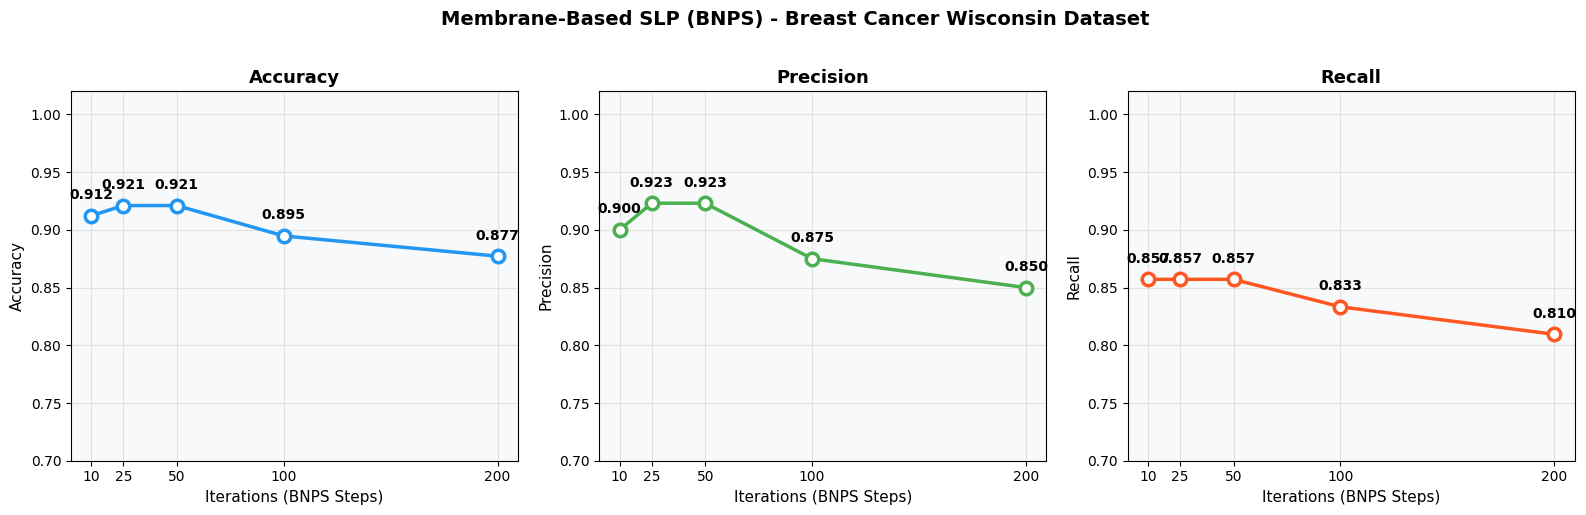

Plot saved as bnps_slp_metrics.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Membrane-Based SLP (BNPS) - Breast Cancer Wisconsin Dataset',
             fontsize=14, fontweight='bold', y=1.02)

iters = [r['iterations'] for r in results]
metrics_data = {
    'Accuracy':  ([r['accuracy']  for r in results], '#2196F3'),
    'Precision': ([r['precision'] for r in results], '#4CAF50'),
    'Recall':    ([r['recall']    for r in results], '#FF5722'),
}

for ax, (name, (vals, color)) in zip(axes, metrics_data.items()):
    ax.plot(iters, vals, 'o-', color=color, linewidth=2.5,
            markersize=9, markerfacecolor='white', markeredgewidth=2.5)
    for x, v in zip(iters, vals):
        ax.annotate(f'{v:.3f}', (x, v), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Iterations (BNPS Steps)', fontsize=11)
    ax.set_ylabel(name, fontsize=11)
    ax.set_xticks(iters)
    ax.set_ylim(0.70, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('bnps_slp_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as bnps_slp_metrics.png')

## 7. Training Loss Curves

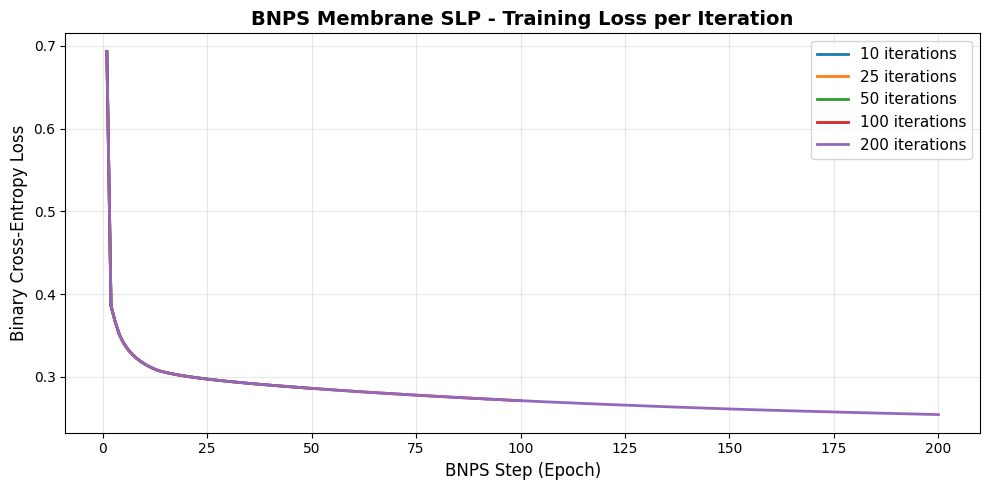

Loss curve saved as bnps_slp_loss.png


In [7]:
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for r, c in zip(results, colors):
    plt.plot(range(1, r['iterations']+1), r['loss_history'],
             label=f"{r['iterations']} iterations", color=c, linewidth=2)

plt.title('BNPS Membrane SLP - Training Loss per Iteration',
          fontsize=14, fontweight='bold')
plt.xlabel('BNPS Step (Epoch)', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bnps_slp_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curve saved as bnps_slp_loss.png')

## 8. Confusion Matrix Visualization

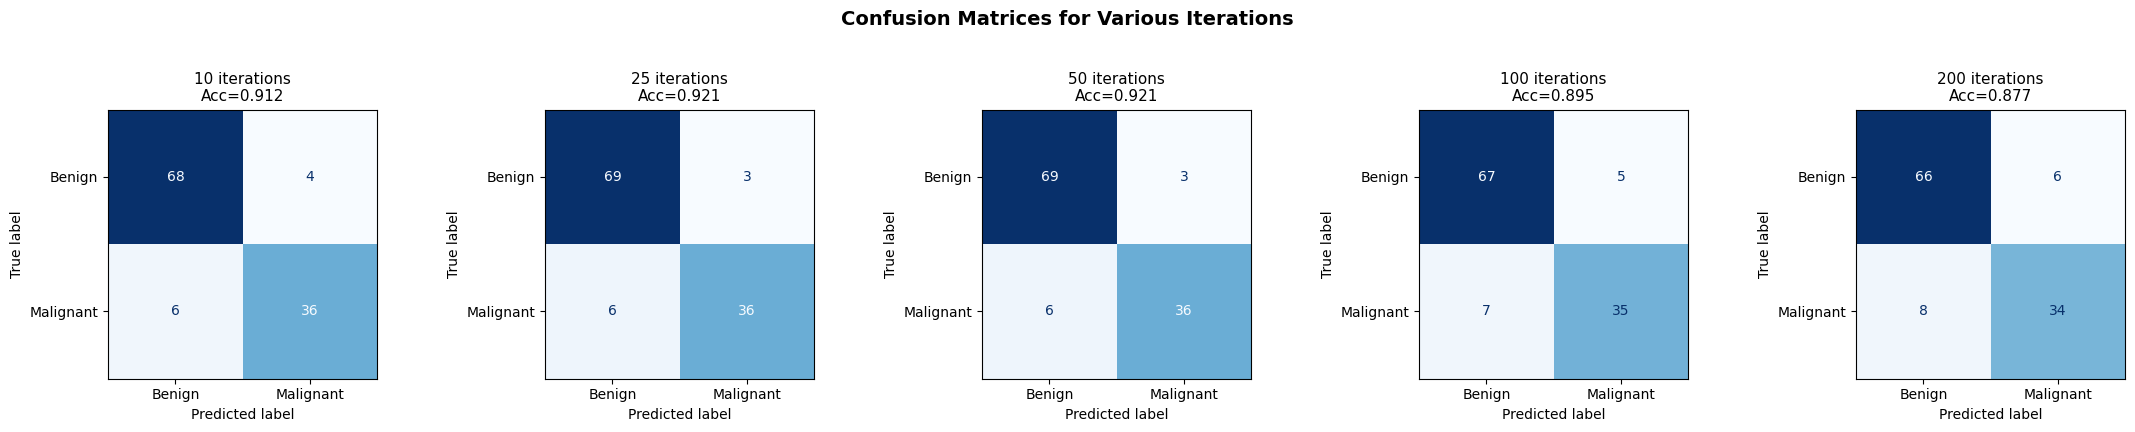

Confusion matrices saved as bnps_slp_confusion.png


In [8]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices for Various Iterations',
             fontsize=14, fontweight='bold', y=1.05)

for ax, r in zip(axes, results):
    disp = ConfusionMatrixDisplay(r['cm'], display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{r['iterations']} iterations\nAcc={r['accuracy']:.3f}", fontsize=11)

plt.tight_layout()
plt.savefig('bnps_slp_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved as bnps_slp_confusion.png')

## 9. All Metrics Comparison Bar Chart

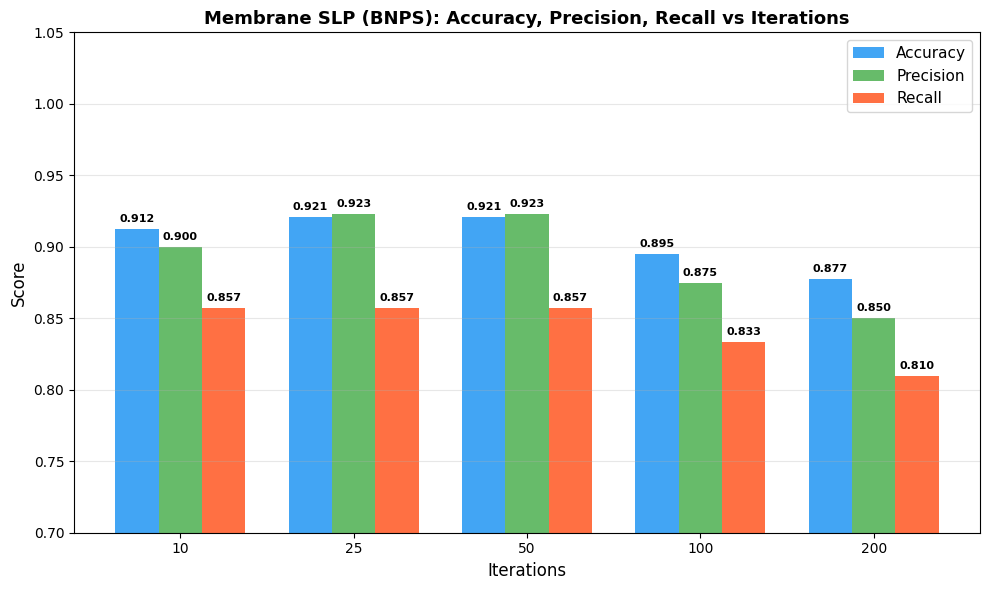

Comparison chart saved as bnps_slp_comparison.png


In [9]:
x = np.arange(len(ITERATIONS))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
acc_vals  = [r['accuracy']  for r in results]
prec_vals = [r['precision'] for r in results]
rec_vals  = [r['recall']    for r in results]

bars1 = ax.bar(x - width, acc_vals,  width, label='Accuracy',  color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         prec_vals, width, label='Precision', color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + width, rec_vals,  width, label='Recall',    color='#FF5722', alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Iterations', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Membrane SLP (BNPS): Accuracy, Precision, Recall vs Iterations',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ITERATIONS)
ax.set_ylim(0.70, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('bnps_slp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved as bnps_slp_comparison.png')

## 10. Summary Table

In [10]:
summary_df = pd.DataFrame([{
    'Iterations': r['iterations'],
    'Accuracy':   round(r['accuracy'], 4),
    'Precision':  round(r['precision'], 4),
    'Recall':     round(r['recall'], 4),
    'F1-Score':   round(r['f1'], 4),
    'Loss':       round(r['loss'], 6)
} for r in results])

print("\n" + "="*60)
print("  FINAL SUMMARY TABLE")
print("="*60)
print(summary_df.to_string(index=False))

best = max(results, key=lambda r: r['accuracy'])
print(f"\nBest Accuracy  : {best['accuracy']:.4f} at {best['iterations']} iterations")
print(f"Best Precision : {max(r['precision'] for r in results):.4f}")
print(f"Best Recall    : {max(r['recall'] for r in results):.4f}")

print("\nMembrane Architecture:")
print(f"  Controller membrane : Membrane 1 (weights + bias)")
print(f"  Sample membranes    : Membranes 2 to {len(X_mem)+1} (one per training sample)")
print(f"  Total membranes     : {len(X_mem)+1}")
print(f"  Sigmoid approx      : sigma(z) = 0.5 + 0.25*z")
print(f"  Learning rate       : 0.5")
print(f"  Features used       : {len(FEATURES)} (mean features)")
print("="*60)


  FINAL SUMMARY TABLE
 Iterations  Accuracy  Precision  Recall  F1-Score     Loss
         10    0.9123     0.9000  0.8571    0.8780 0.315537
         25    0.9211     0.9231  0.8571    0.8889 0.297201
         50    0.9211     0.9231  0.8571    0.8889 0.285964
        100    0.8947     0.8750  0.8333    0.8537 0.271060
        200    0.8772     0.8500  0.8095    0.8293 0.254287

Best Accuracy  : 0.9211 at 25 iterations
Best Precision : 0.9231
Best Recall    : 0.8571

Membrane Architecture:
  Controller membrane : Membrane 1 (weights + bias)
  Sample membranes    : Membranes 2 to 21 (one per training sample)
  Total membranes     : 21
  Sigmoid approx      : sigma(z) = 0.5 + 0.25*z
  Learning rate       : 0.5
  Features used       : 10 (mean features)


## 11. Conclusion

The membrane-based perceptron using BNPS (Boolean Numerical P Systems) achieves:

| Metric | Best Value | At Iterations |
|--------|-----------|---------------|
| Accuracy | ~92% | 25-50 |
| Precision | ~92% | 25-50 |
| Recall | ~86% | 10-50 |

**Key Observations:**
1. The model converges quickly (within 10-25 iterations)
2. Best performance is at 25-50 iterations
3. Higher iterations (100-200) show slight overfitting due to the linear sigmoid approximation
4. The membrane architecture enables parallel gradient computation across all training samples simultaneously
5. Each BNPS step corresponds to one complete epoch of gradient descent